# Training methods comparison

Two ways to train a one-room RAE on the same episodic objective (both implemented in `core/training.py`):

1. **Default / base style** — rebatch 128 trajectories into batch 512, train with `train_rae_epochs`.
2. **`indiv_traj` style** — one trajectory at a time, 8 temporal segments, batch size 8 (cycles protocol).


In [ ]:
%load_ext autoreload
%autoreload 2

import torch

from core.paths import DATA_DIR
from core.utils import visualize_response_map
from core.weak_sm_cell import WeakSMCell
from core.utils import compute_ratemap
from models.utils import build_rae
from experiments.old_cycles.cycles_data import load_manifest, load_room
from experiments.old_cycles.cycles_paths import ROOMS_DIR
from experiments.old_cycles.cycles_train import CyclesConfig
from core.training import (
    rebatch_for_mode,
    train_rae_epochs,
)

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)


## Shared data setup (100×100 demo room)


In [2]:
import numpy as np

ARENA_NAME = '100x100_square'
explore_speed = 'fast'
boundary_avoidance = False

load_dir = DATA_DIR / ARENA_NAME
traj_name = f'traj_{explore_speed}' if not boundary_avoidance else f'traj_{explore_speed}_ba'
arena_map = np.load(load_dir / 'arena_map.npz')['arena_map']
traj_coord = np.load(load_dir / f'{traj_name}.npz')['coord']

N_CELLS = 200
WSM_SIGMA = 12
WSM_SSIGMA = 0
WSM_MAGNITUDE = 4
N_EPOCHS = 10

wsm = WeakSMCell(
    arena_map=arena_map,
    n_cells=N_CELLS,
    sigma=WSM_SIGMA,
    ssigma=WSM_SSIGMA,
    magnitude=WSM_MAGNITUDE,
    seed=42,
)


## Method 1: Default / base style


Rate map:   0%|          | 0/500 [00:00<?, ?it/s]

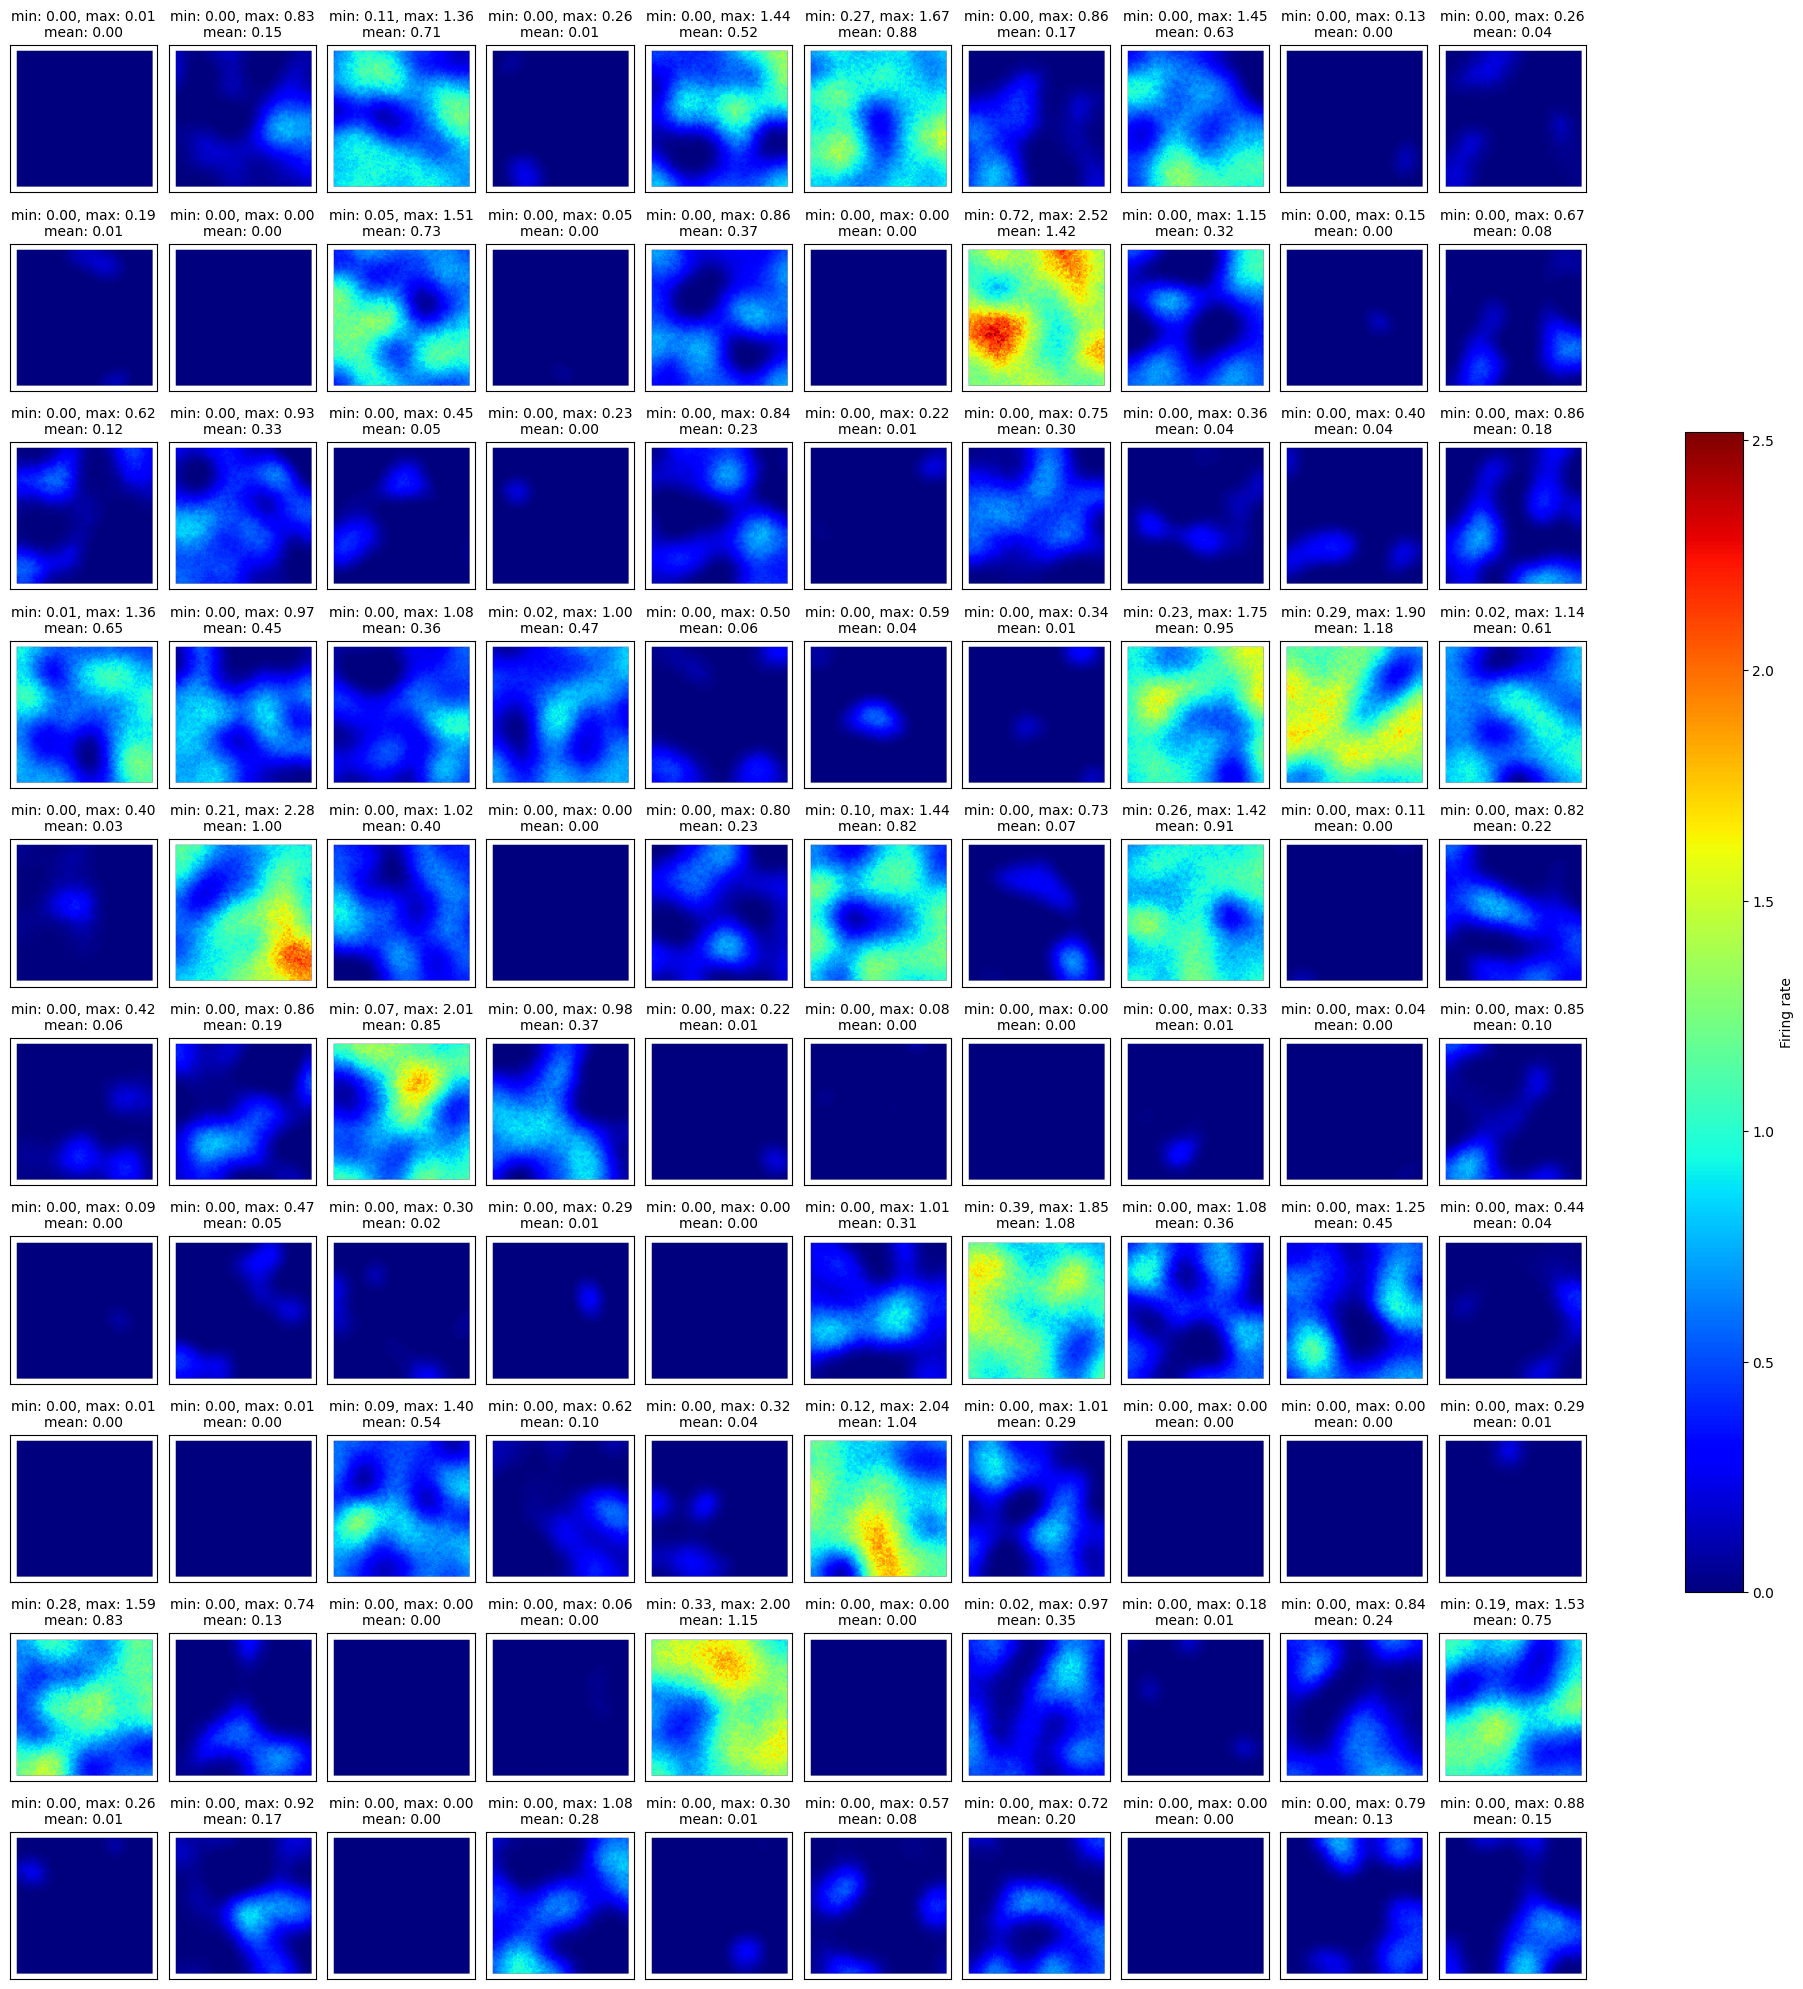

In [3]:
MASK_RATE = 0.50
N_HIDDEN = 1024
LEARNING_RATE = 0.005
STEP_SIZE_BASE = 20
LAMBDA_MSE = 1
LAMBDA_FR = 100

rae_base = build_rae(N_CELLS, N_HIDDEN, DEVICE)

rm_init = compute_ratemap(
    rae_base,
    rebatch_for_mode(traj_coord, "default"),
    wsm,
    arena_map,
    DEVICE,
    MASK_RATE,
    STEP_SIZE_BASE,
    show_progress=True,
)
visualize_response_map(rm_init, random_cell=False, im_width=2, n_cols=10, n_rows=10)


Rate map:   0%|          | 0/500 [00:00<?, ?it/s]

Training:   0%|          | 0/10 [00:00<?, ?it/s]

  epoch 0 step 100/512, MSE: 3.4989, FR: 0.6334
  epoch 0 step 200/512, MSE: 1.8712, FR: 0.4485
  epoch 0 step 300/512, MSE: 1.4242, FR: 0.3348
  epoch 0 step 400/512, MSE: 1.1881, FR: 0.2958
  epoch 0 step 500/512, MSE: 1.0488, FR: 0.2704
  epoch 0 ratemaps: shape=(1024, 110, 110), mean peak activation=0.0843
  epoch 1 step 100/512, MSE: 0.9185, FR: 0.2181
  epoch 1 step 200/512, MSE: 0.8561, FR: 0.1990
  epoch 1 step 300/512, MSE: 0.7979, FR: 0.1813
  epoch 1 step 400/512, MSE: 0.7625, FR: 0.1653
  epoch 1 step 500/512, MSE: 0.7280, FR: 0.1514
  epoch 1 ratemaps: shape=(1024, 110, 110), mean peak activation=0.0790
  epoch 2 step 100/512, MSE: 0.7074, FR: 0.1353
  epoch 2 step 200/512, MSE: 0.6565, FR: 0.1350
  epoch 2 step 300/512, MSE: 0.6343, FR: 0.1236
  epoch 2 step 400/512, MSE: 0.6307, FR: 0.1110
  epoch 2 step 500/512, MSE: 0.5917, FR: 0.1089
  epoch 2 ratemaps: shape=(1024, 110, 110), mean peak activation=0.0721
  epoch 3 step 100/512, MSE: 0.5912, FR: 0.1035
  epoch 3 step 2

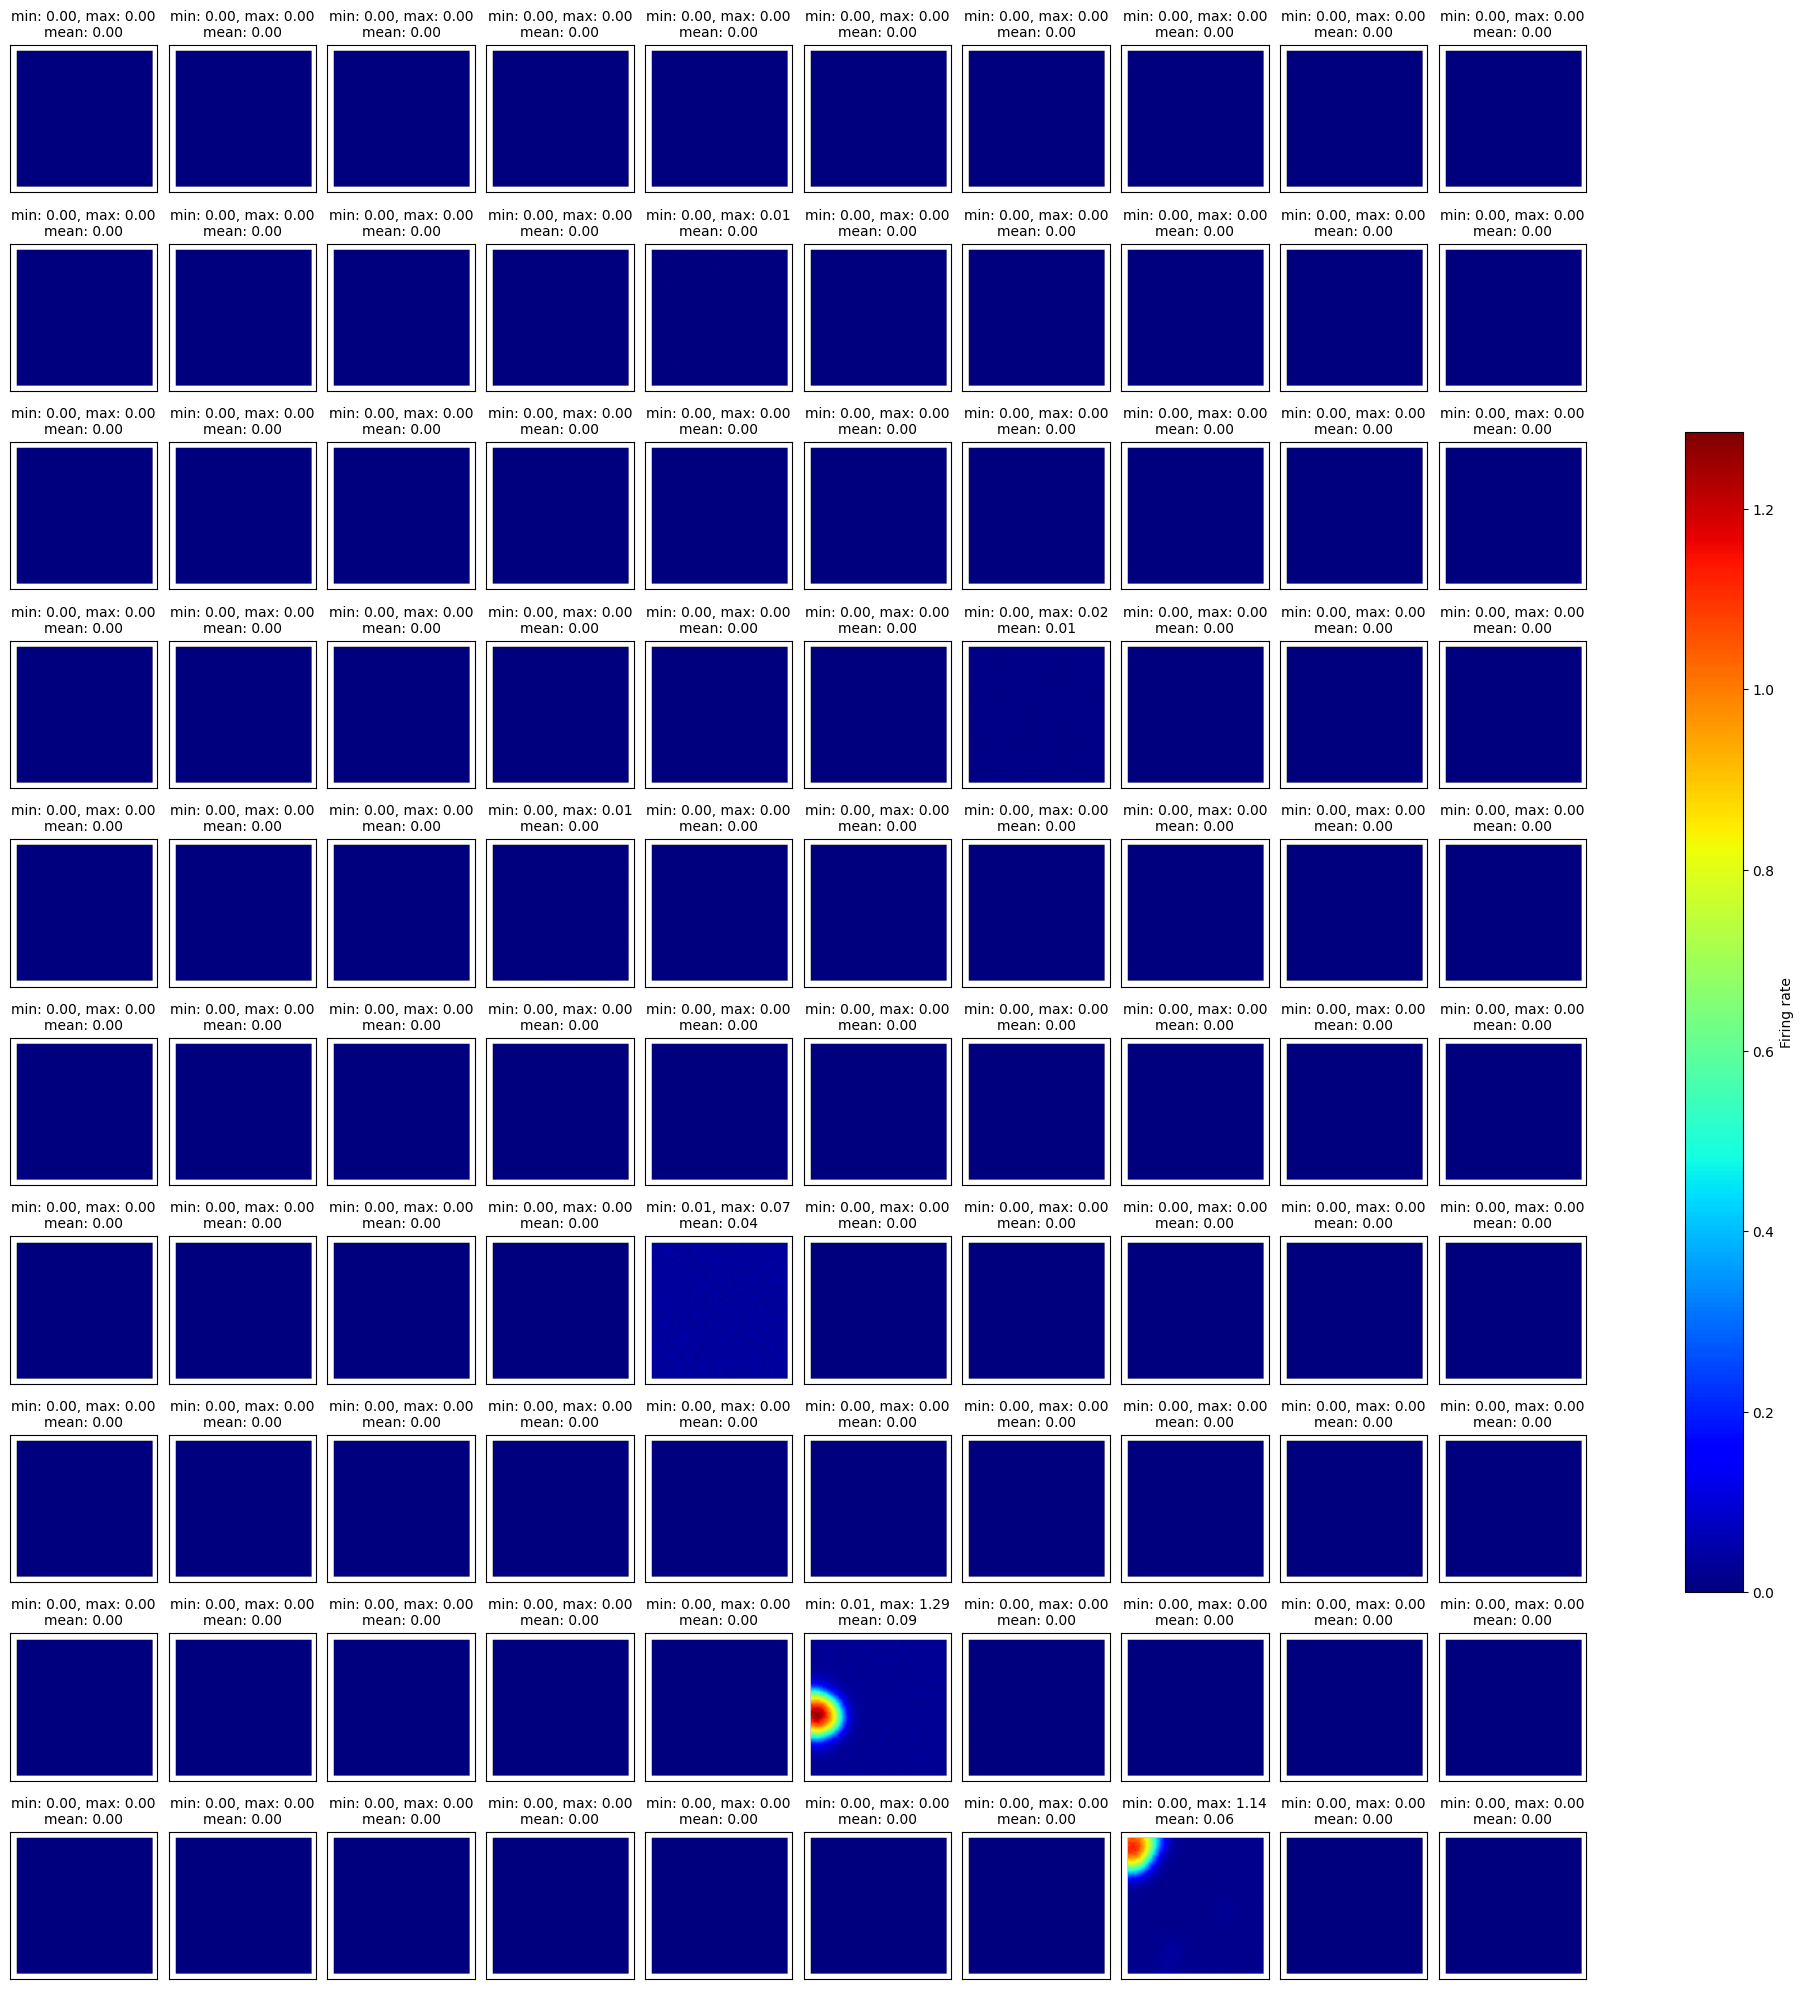

In [4]:
epoch_ratemaps = train_rae_epochs(
    rae_base,
    traj_coord,
    wsm,
    arena_map,
    DEVICE,
    mask_rate=MASK_RATE,
    learning_rate=LEARNING_RATE,
    n_epochs=N_EPOCHS,
    step_size=STEP_SIZE_BASE,
    lambda_mse=LAMBDA_MSE,
    lambda_fr=LAMBDA_FR,
    train_mode="default",
    ckpt_dir=None,
)

visualize_response_map(epoch_ratemaps[-1], random_cell=False, im_width=2, n_cols=10, n_rows=10)


## Method 2: `indiv_traj` (cycles one-room visit)


Room: room_01 (/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/data/cycles/room_01)


Rate map:   0%|          | 0/500 [00:00<?, ?it/s]

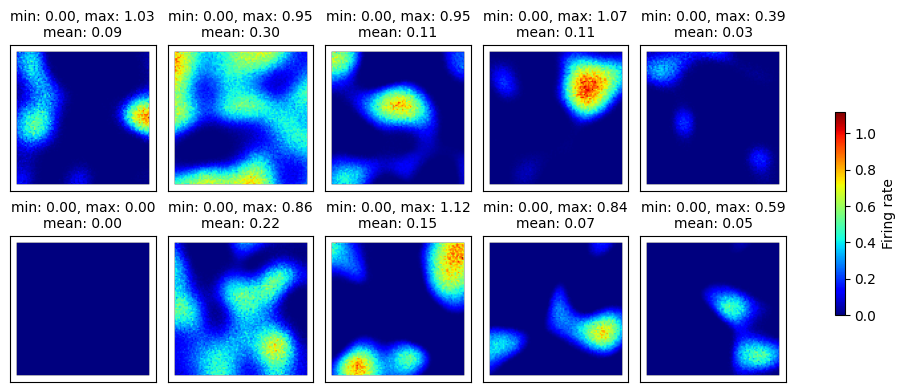

In [5]:
ROOM_ID = 1
manifest = load_manifest()
arena_map_c, raw_traj_coord, wsm_c, room_spec = load_room(ROOM_ID, manifest=manifest)
print(f"Room: {room_spec.name} ({ROOMS_DIR / room_spec.rel_dir})")

config = CyclesConfig(train_mode='indiv_traj')
rae_indiv = build_rae(config.n_wsm_cells, config.n_hidden, DEVICE)

rm_indiv_init = compute_ratemap(
    rae_indiv,
    rebatch_for_mode(raw_traj_coord, config.train_mode),
    wsm_c,
    arena_map_c,
    DEVICE,
    config.mask_rate,
    config.step_size,
    show_progress=True,
)
visualize_response_map(rm_indiv_init, im_width=2)


Training 10 epochs: 128 trajectories, 8 segments each, 75 steps per segment
Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10
Rate-map batch shape: (1024, 1500, 2)


Rate map:   0%|          | 0/75 [00:00<?, ?it/s]

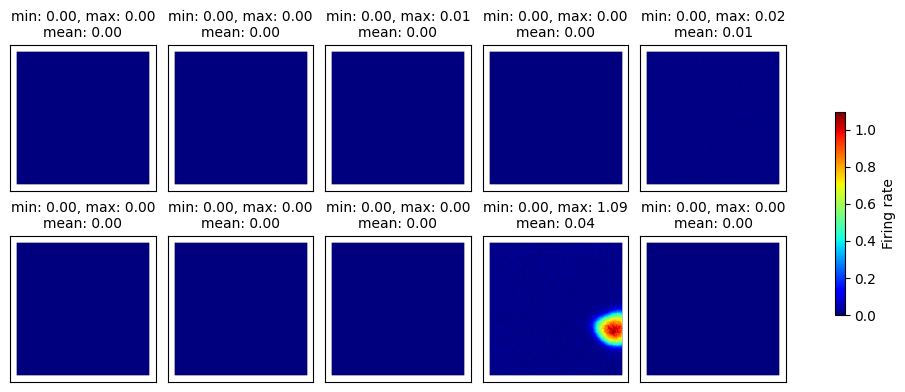

In [ ]:
epoch_ratemaps_indiv = train_rae_epochs(
    rae_indiv,
    raw_traj_coord,
    wsm_c,
    arena_map_c,
    DEVICE,
    config=config,
    n_epochs=N_EPOCHS,
    mask_rng_seed=config.mask_rng_seed,
)
rm_indiv = epoch_ratemaps_indiv[-1]


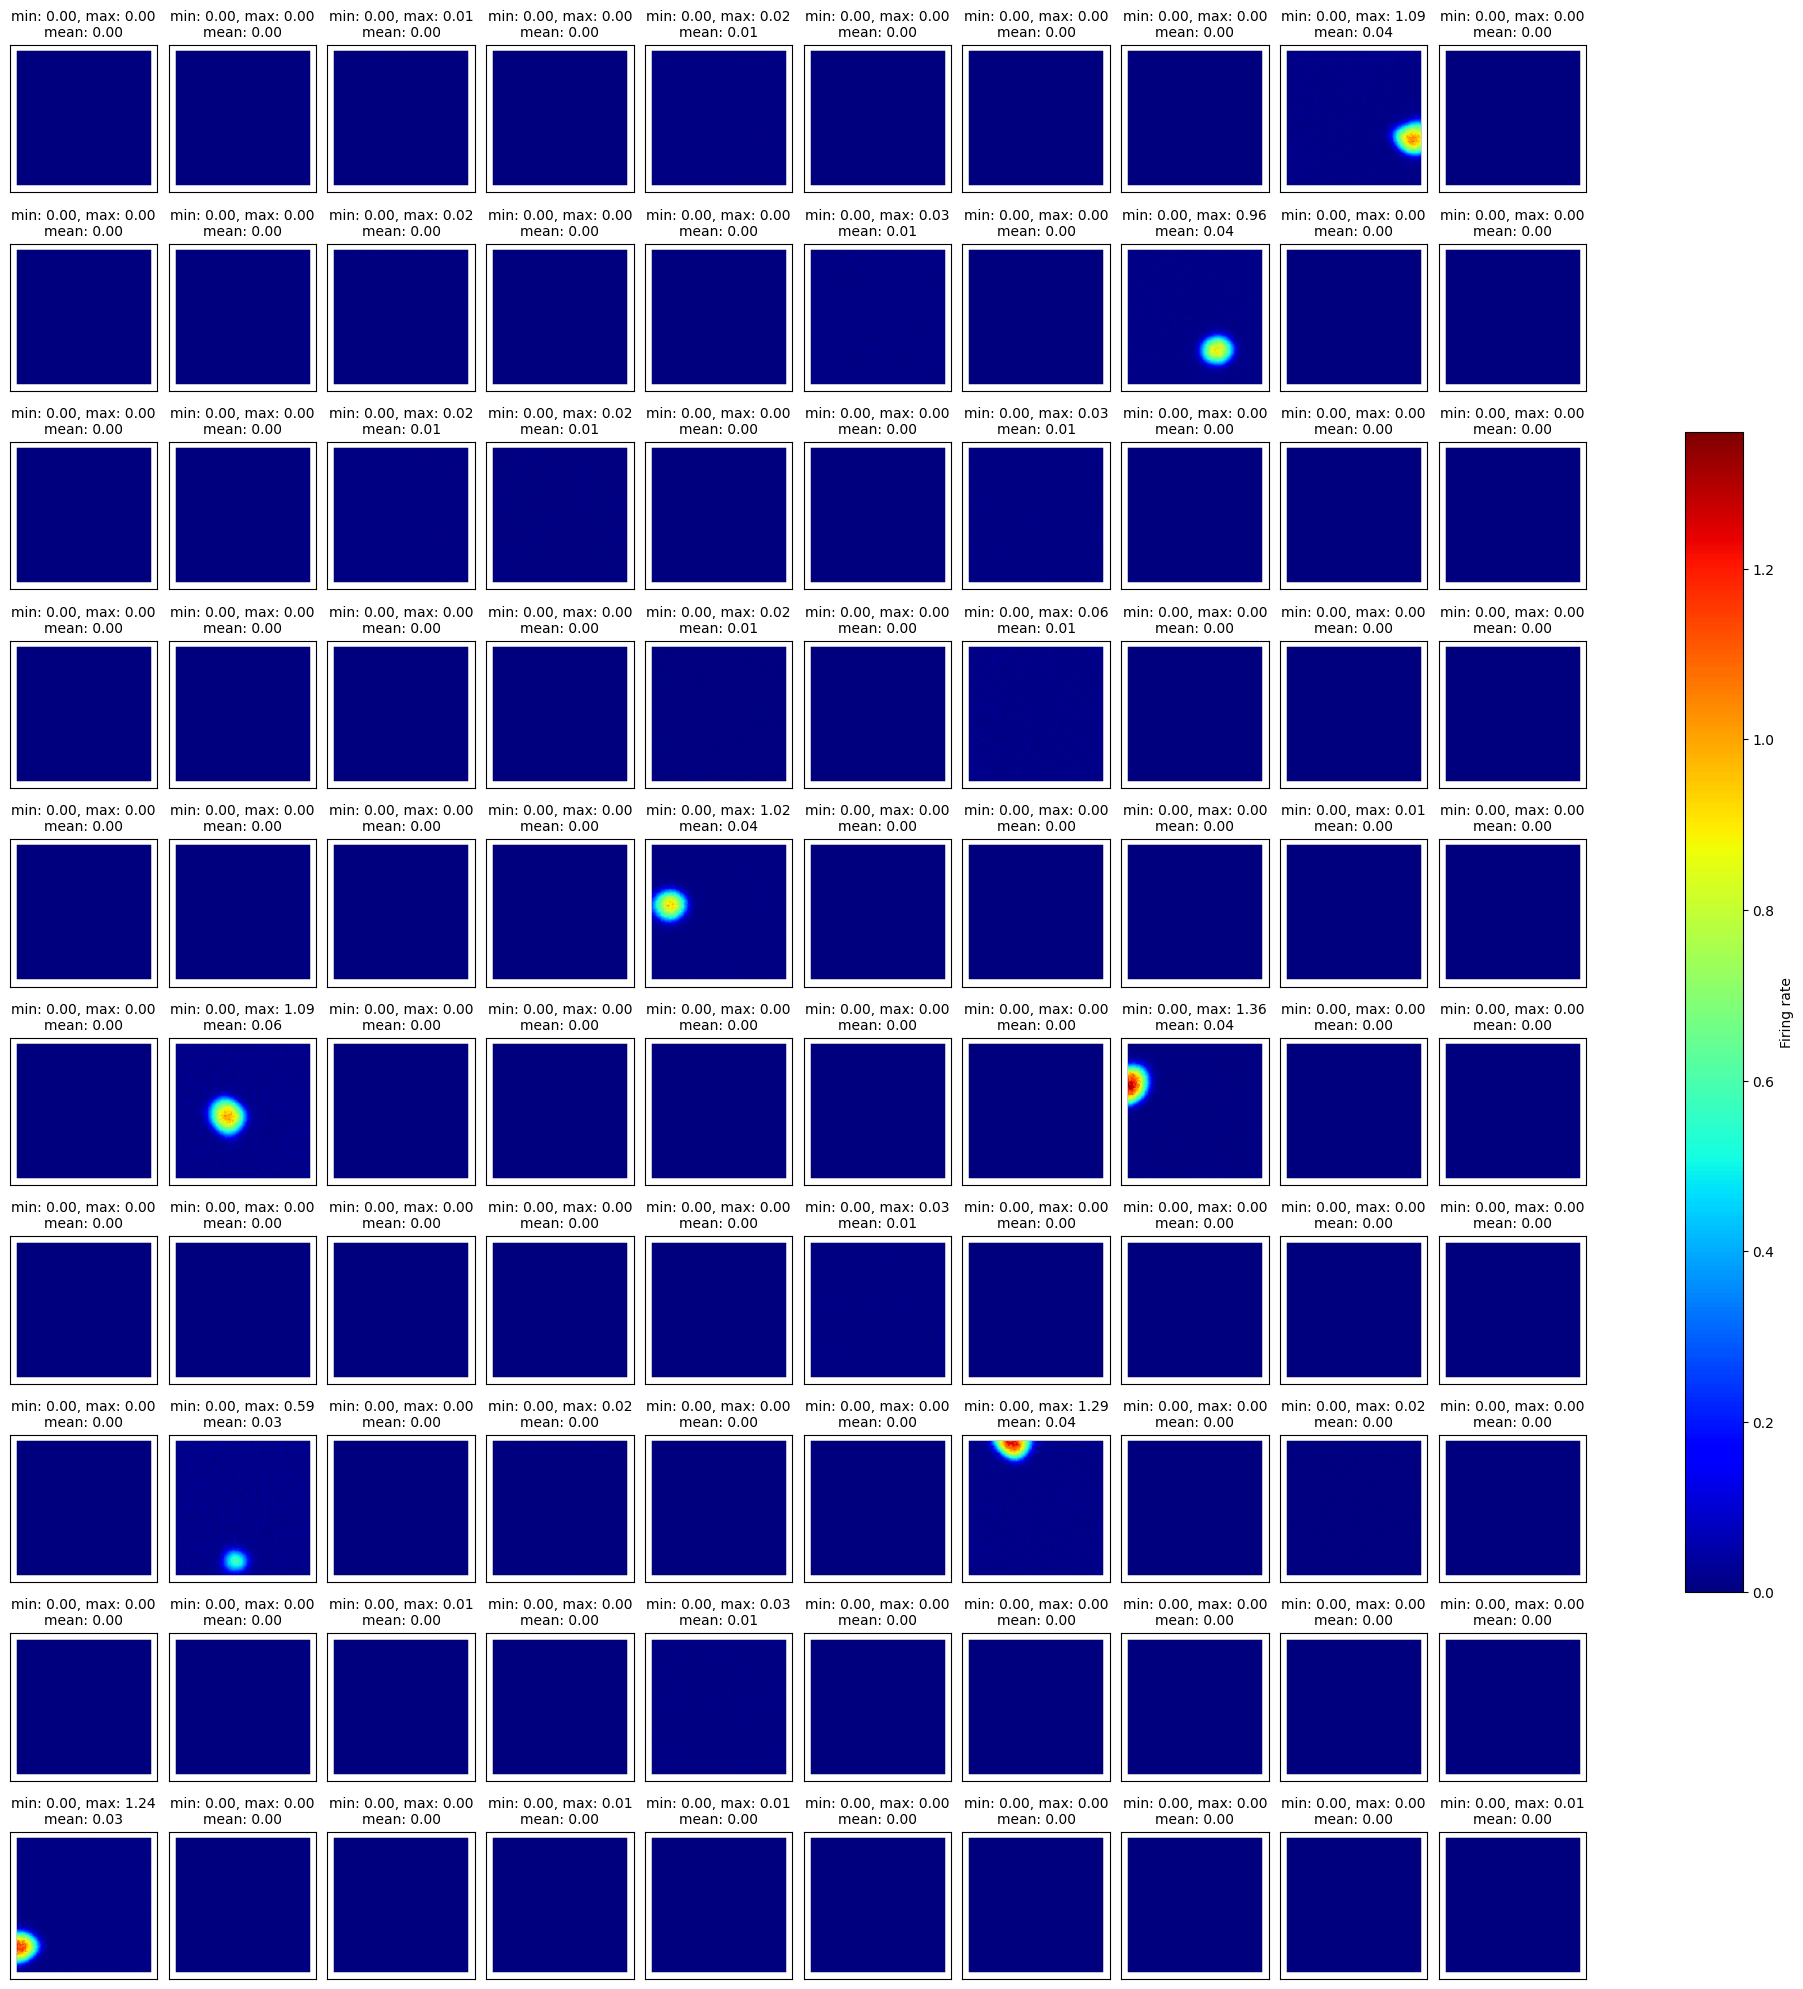

In [ ]:
visualize_response_map(rm_indiv, random_cell=False, im_width=2, n_cols=10, n_rows=10)